<a href="https://colab.research.google.com/github/e-junior/Grupo16TechChallenge/blob/main/data_consumo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [29]:
df_oiv = pd.read_csv('data oiv.csv', encoding='latin1', sep=';')

In [30]:
df_oiv.dtypes

,0
Continent,object
Region/Country,object
Product,object
Variable,object
Year,float64
Unit,object
Quantity,object


In [93]:
df_oiv['Year'] = df_oiv['Year'].astype(str)

KeyError: 'Year'

In [100]:
df_oiv['volume'] = df_oiv['volume'].str.replace(' ', '', regex=False).astype(float)

AttributeError: Can only use .str accessor with string values!

In [32]:
df_oiv.columns


Index(['Continent', 'Region/Country', 'Product', 'Variable', 'Year', 'Unit',
       'Quantity'],
      dtype='object')

In [34]:
df_oiv.columns = ['continente','pais', 'produto', 'variavel', 'ano', 'unidade', 'volume']


In [ ]:
df_oiv.isna().isnull().sum()

In [ ]:
df_oiv=df_oiv.dropna()
print(df_oiv)

In [61]:
consumo_vinho=df_oiv[df_oiv['produto']=='Wine']

In [78]:
consumo_vinho = consumo_vinho.sort_values(by = 'continente')

In [82]:
consumo_vinho['continente'].unique()

array(['Africa', 'America', 'Asia', 'Europe', 'Global', 'Oceania'],
      dtype=object)

In [84]:
#isolei analise por continente
consumo_vinho_africa = consumo_vinho.loc[consumo_vinho['continente'] == 'Africa']

In [ ]:
#Alguns valores de volume estavam separados em milhar e centena, alem  de estarem no tipo string
consumo_vinho_africa['volume'] = consumo_vinho_africa['volume'].str.replace(' ', '', regex=False).astype(float)

##isolando continente africando

In [87]:
#isolei paises para analise mais conectada com os dados que já temos
consumo_vinho_africa['pais'].unique()

array(['Sierra Leone', 'Senegal', 'Ghana', 'Sao Tome and Principe',
       'Gabon', 'Gambia', "Côte d'Ivoire", 'Congo',
       'Congo (the Democratic Republic of the)', 'Egypt', 'Eswatini',
       'Ethiopia', 'Sudan', 'South Africa', 'Libya', 'Madagascar',
       'Morocco', 'Lesotho', 'Mozambique', 'Liberia', 'Mauritania',
       'Mauritius', 'Angola', 'Djibouti', 'Seychelles', 'Malawi', 'Mali',
       'Guinea', 'Guinea-Bissau', 'Namibia', 'Nigeria', 'Kenya', 'Niger',
       'Comoros', 'Somalia', 'Burkina Faso', 'Rwanda', 'Burundi',
       'Tunisia', 'Uganda', 'Botswana', 'Cabo Verde', 'Zambia', 'Algeria',
       'Tanzania, the United Republic of', 'Togo', 'Zimbabwe',
       'Central African Republic', 'Saint Helena', 'Chad',
       'Reunion island', 'Benin', 'Cameroon'], dtype=object)

paises para pesquisa (AFRICA): Egypt Madagascar Mozambique, Liberia Angola Niger South Africa

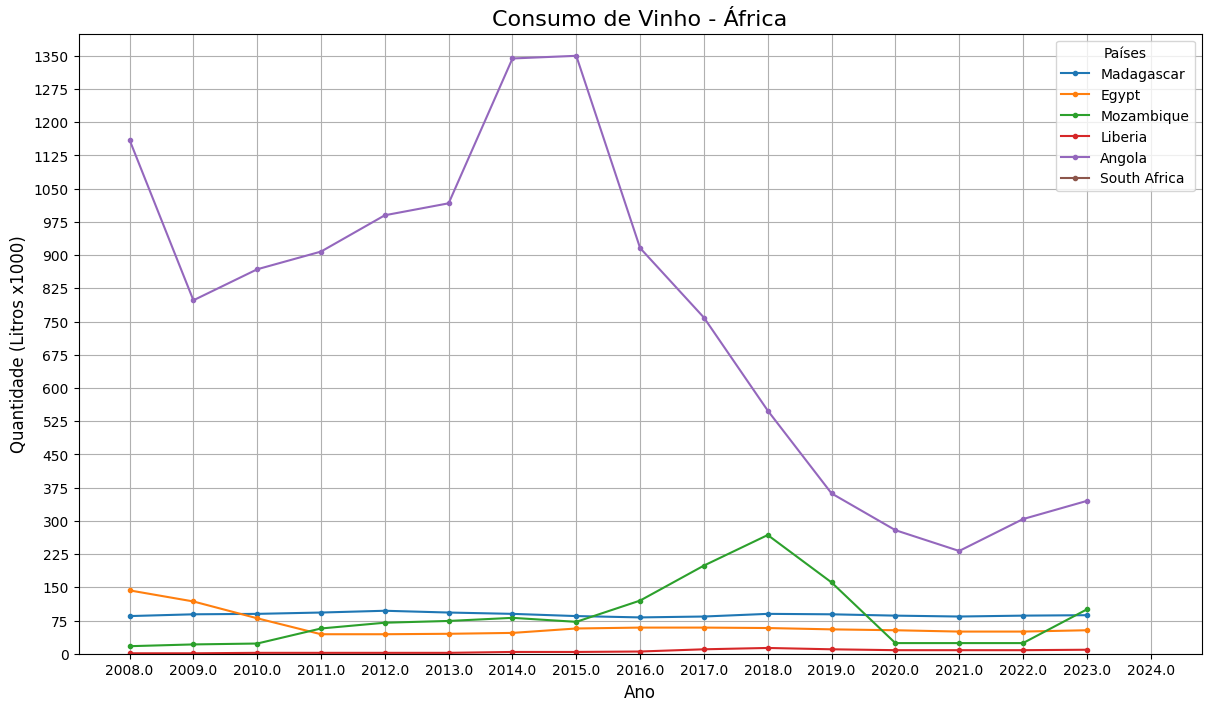

In [117]:
paises_para_plotar = ['Madagascar', 'Egypt', 'Mozambique', 'Liberia', 'Angola', 'South Africa']
df_filtrado = consumo_vinho_africa[ consumo_vinho_africa['pais'].isin(paises_para_plotar)]
# 2. Criar a Figura e os Eixos (a "tela de pintura")
# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')

    # Plota os dados: Ano no eixo X, Quantidade no eixo Y
    # O 'label' é crucial para a legenda saber o nome de cada linha
    ax.plot(df_pais['ano'], df_pais['volume'], marker='.', linestyle='-', label=pais)

# 4. Adicionar os toques finais para deixar o gráfico profissional
ax.set_title('Consumo de Vinho - África', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade (Litros x1000)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo

# Adiciona a legenda para identificar qual linha corresponde a qual país
ax.legend(title='Países')
ax.set_ylim(0, 1400)
ticks_person = np.arange(0, 1401, 75) # Começa em 0, vai até 40M, de 5 em 5M
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

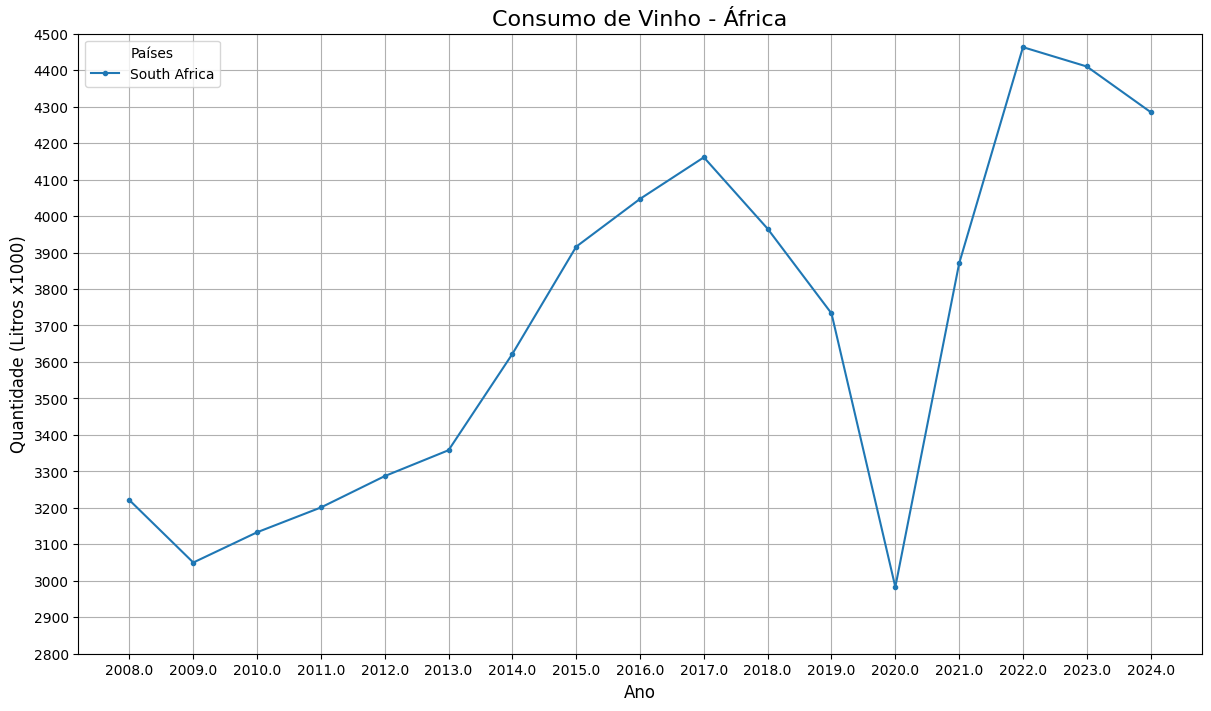

In [125]:
paises_para_plotar = [ 'South Africa']
df_filtrado = consumo_vinho_africa[ consumo_vinho_africa['pais'].isin(paises_para_plotar)]
# 2. Criar a Figura e os Eixos (a "tela de pintura")
# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')

    # Plota os dados: Ano no eixo X, Quantidade no eixo Y
    # O 'label' é crucial para a legenda saber o nome de cada linha
    ax.plot(df_pais['ano'], df_pais['volume'], marker='.', linestyle='-', label=pais)

# 4. Adicionar os toques finais para deixar o gráfico profissional
ax.set_title('Consumo de Vinho - África', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade (Litros x1000)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo

# Adiciona a legenda para identificar qual linha corresponde a qual país
ax.legend(title='Países')
ax.set_ylim(2800, 4500)
ticks_person = np.arange(2800, 4501, 100) # Começa em 0, vai até 40M, de 5 em 5M
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

*analise*

 aparentemente, o unico pais que talvez nos interesse seja Africa do Sul, pelas conexoes que temos em outros dados.

##Isolando o continente Americano

In [127]:
consumo_vinho_america = consumo_vinho.loc[consumo_vinho['continente'] == 'America']
consumo_vinho_america

,continente,pais,produto,variavel,ano,unidade,volume
7542,America,United States of America,Wine,Consumption,2008.0,1000 hl,27 700
6745,America,Peru,Wine,Consumption,2008.0,1000 hl,722
4707,America,Barbados,Wine,Consumption,2008.0,1000 hl,25
4757,America,Belize,Wine,Consumption,2008.0,1000 hl,4
5744,America,Guyana,Wine,Consumption,2008.0,1000 hl,0
...,...,...,...,...,...,...,...
5047,America,Chile,Wine,Consumption,2024.0,1000 hl,1 890
5688,America,Guadeloupe,Wine,Consumption,2016.0,1000 hl,0
5046,America,Chile,Wine,Consumption,2023.0,1000 hl,1 730
5338,America,Dominican Republic,Wine,Consumption,2023.0,1000 hl,118


In [128]:
#acertando srg>float e eliminando espacoes entre milhar e centenas do 'volume'
consumo_vinho_america['volume'] = consumo_vinho_america['volume'].str.replace(' ', '', regex=False).astype(float)

In [129]:
consumo_vinho_america['pais'].unique()

array(['United States of America', 'Peru', 'Barbados', 'Belize', 'Guyana',
       'Saint Kitts and Nevis', 'Haiti', 'Panama', 'Mexico', 'Argentina',
       'Antigua and Barbuda', 'Martinique', 'Venezuela', 'Paraguay',
       'Montserrat', 'Guadeloupe', 'Honduras', 'El Salvador',
       'Netherlands Antilles', 'Costa Rica', 'Suriname', 'Bermuda',
       'Nicaragua', 'Brazil', 'French Guiana', 'Chile', 'Cuba', 'Jamaica',
       'Dominica', 'Dominican Republic', 'Ecuador',
       'Saint Vincent and the Grenadines', 'Bolivia', 'Grenada',
       'Saint Lucia', 'Uruguay', 'Greenland', 'Canada',
       'Saint Pierre And Miquelon', 'Colombia', 'Bahamas',
       'Trinidad and Tobago'], dtype=object)

*PAISES PARA ANÁLISE* - 'United States of America', 'Peru', 'Haiti', 'Mexico', 'Argentina', 'Paraguai',  'Brazil', 'Uruguay', 'Canada', 'Colombia'

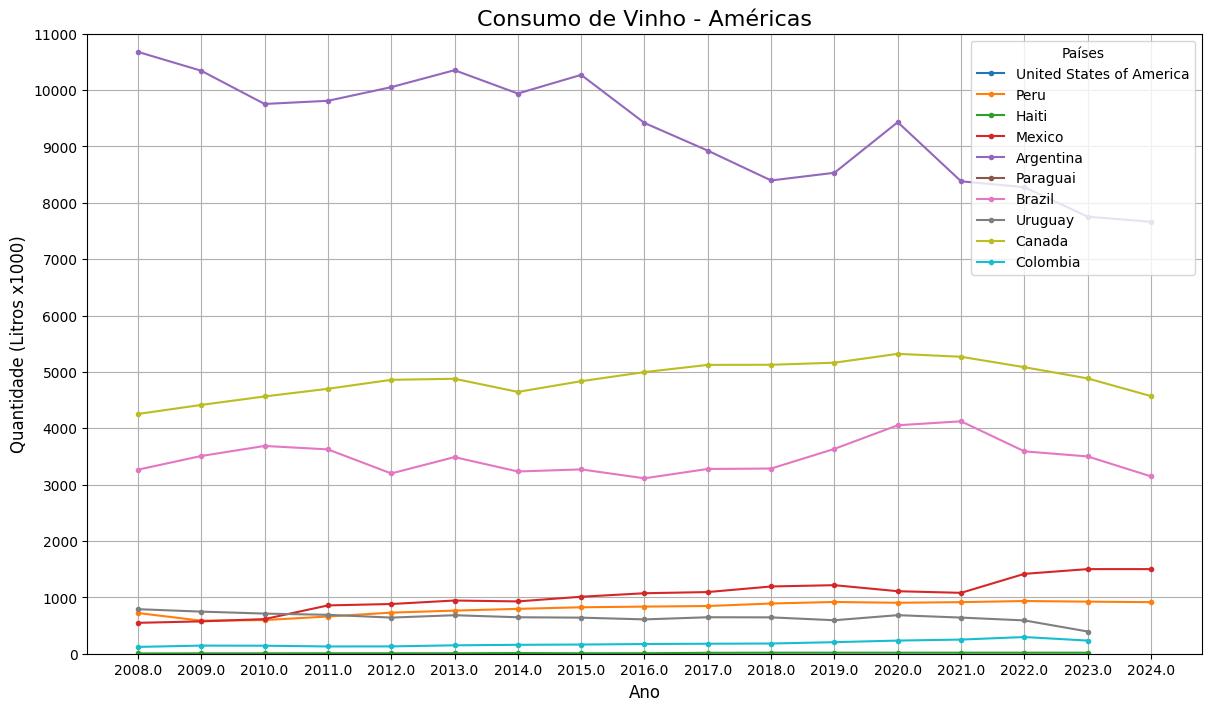

In [136]:
paises_para_plotar = [ 'United States of America', 'Peru', 'Haiti', 'Mexico', 'Argentina', 'Paraguai',  'Brazil', 'Uruguay', 'Canada', 'Colombia'  ]
df_filtrado = consumo_vinho_america[ consumo_vinho_america['pais'].isin(paises_para_plotar)]
# 2. Criar a Figura e os Eixos (a "tela de pintura")
# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')

    # Plota os dados: Ano no eixo X, Quantidade no eixo Y
    # O 'label' é crucial para a legenda saber o nome de cada linha
    ax.plot(df_pais['ano'], df_pais['volume'], marker='.', linestyle='-', label=pais)

# 4. Adicionar os toques finais para deixar o gráfico profissional
ax.set_title('Consumo de Vinho - Américas', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade (Litros x1000)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo

# Adiciona a legenda para identificar qual linha corresponde a qual país
ax.legend(title='Países')
ax.set_ylim(00, 11000)
ticks_person = np.arange(0, 11001, 1000) # Começa em 0, vai até 40M, de 5 em 5M
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

Único em clara alta - México

Isolando o continente Asiático

In [137]:
consumo_vinho_asia = consumo_vinho.loc[consumo_vinho['continente'] == 'Asia']
consumo_vinho_asia

,continente,pais,produto,variavel,ano,unidade,volume
6373,Asia,Mongolia,Wine,Consumption,2008.0,1000 hl,16
7316,Asia,Syrian Arab Republic,Wine,Consumption,2008.0,1000 hl,3
7639,Asia,Yemen,Wine,Consumption,2008.0,1000 hl,0
6762,Asia,Philippines,Wine,Consumption,2008.0,1000 hl,99
7234,Asia,State of Palestine,Wine,Consumption,2008.0,1000 hl,0
...,...,...,...,...,...,...,...
6744,Asia,People's Republic of China,Wine,Consumption,2024.0,1000 hl,5 526
6844,Asia,Republic of Türkiye,Wine,Consumption,2024.0,1000 hl,694
5580,Asia,Georgia,Wine,Consumption,2024.0,1000 hl,1 199
5971,Asia,Japan,Wine,Consumption,2024.0,1000 hl,3 090


In [139]:
#acertando srg>float e eliminando espacoes entre milhar e centenas do 'volume'
consumo_vinho_asia['volume'] = consumo_vinho_asia['volume'].str.replace(' ', '', regex=False).astype(float)

In [140]:
consumo_vinho_asia['pais'].unique()

array(['Mongolia', 'Syrian Arab Republic', 'Yemen', 'Philippines',
       'State of Palestine', 'Saudi Arabia', 'Tajikistan', 'Vietnam',
       'Afghanistan', 'Pakistan', 'Turkmenistan', 'Republic of Türkiye',
       'Thailand', 'Nepal', 'Myanmar', 'Uzbekistan', 'Singapore',
       'Sri Lanka', "People's Republic of China", 'Timor-Leste',
       'Kazakhstan', 'Georgia', 'Kyrgyzstan', 'Jordan',
       'China, Taiwan Province of', 'China, Macao SAR', 'India',
       'Indonesia', 'Brunei Darussalam', 'Cambodia', 'Japan',
       'China, Hong Kong SAR', 'Bangladesh', 'Azerbaijan', 'Bahrain',
       'Lebanon', 'Maldives', 'Armenia', 'Malaysia', 'Iran', 'Iraq',
       "Lao People's Democratic Republic", 'Israel',
       'Korea (the Republic of)'], dtype=object)

*paises para analise* - Vietnam , People's Republic of China, India

paises com restrição de venda/consumo de alcool: Arábia Saudita

Irã

Paquistão

Afeganistão

Iêmen

Brunei Darussalam

Maldivas

Malásia

tirei china e korea, macao, japan, bharain  para avaliar os menores

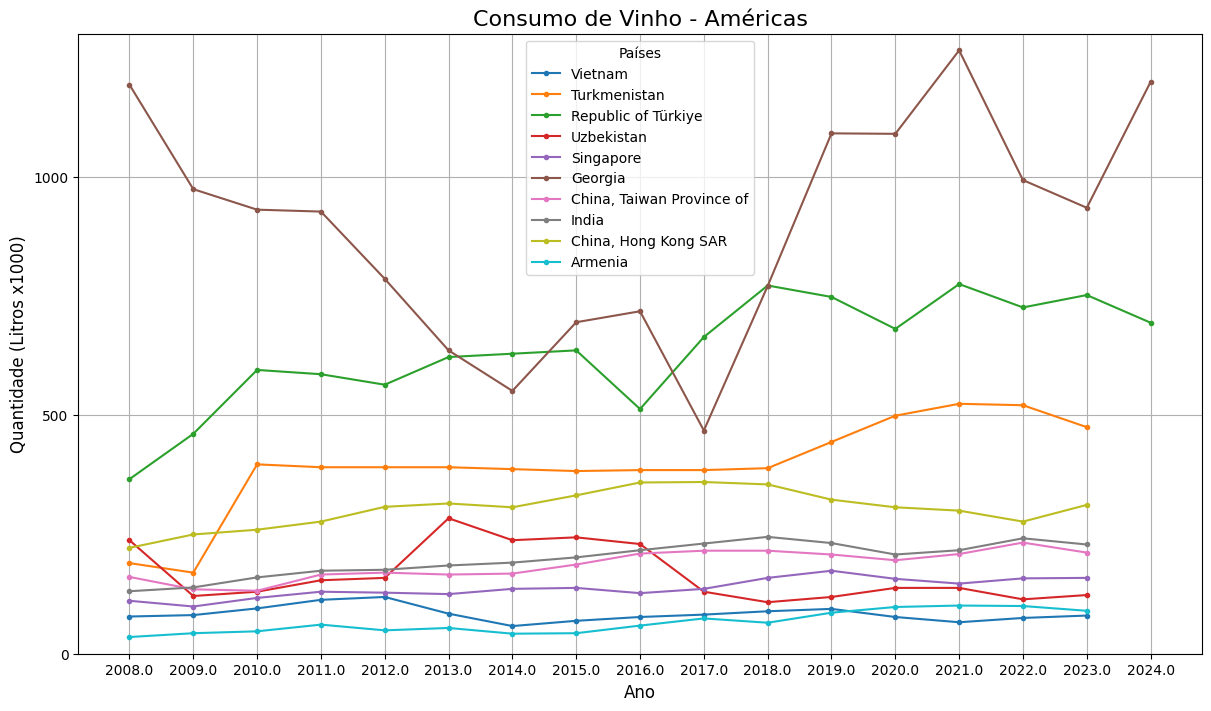

In [181]:
paises_para_plotar = [
        'Vietnam',
         'Turkmenistan', 'Republic of Türkiye',
        'Uzbekistan', 'Singapore',
       'Georgia',
       'China, Taiwan Province of',  'India',
        'China, Hong Kong SAR',
      'Armenia']
df_filtrado = consumo_vinho_asia[ consumo_vinho_asia['pais'].isin(paises_para_plotar)]
# 2. Criar a Figura e os Eixos (a "tela de pintura")
# figsize define o tamanho, e constrained_layout ajuda a organizar os elementos
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# 3. Iterar sobre cada país e plotar seus dados
for pais in paises_para_plotar:
    # Filtra o DataFrame para obter os dados apenas do país atual do loop
    df_pais = df_filtrado[df_filtrado['pais'] == pais]

    # Ordena os dados por ano para garantir que a linha seja desenhada corretamente
    df_pais = df_pais.sort_values(by='ano')

    # Plota os dados: Ano no eixo X, Quantidade no eixo Y
    # O 'label' é crucial para a legenda saber o nome de cada linha
    ax.plot(df_pais['ano'], df_pais['volume'], marker='.', linestyle='-', label=pais)

# 4. Adicionar os toques finais para deixar o gráfico profissional
ax.set_title('Consumo de Vinho - Américas', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade (Litros x1000)', fontsize=12)
ax.grid(True) # Adiciona uma grade de fundo

# Adiciona a legenda para identificar qual linha corresponde a qual país
ax.legend(title='Países')
ax.set_ylim(0, 1300)
ticks_person = np.arange(0, 1301, 500) # Começa em 0, vai até 40M, de 5 em 5M
ax.set_yticks(ticks_person)
# 5. Exibir o gráfico final
plt.show()

**COMENTÁRIOS**: